Problem Statement:

The objective of this project is to build an Artificial Neural Network (ANN) model to predict employee attrition (Stayed or Left).

This is a binary classification problem where the goal is to classify employees based on their likelihood of leaving the company.

Additionally, the project aims to develop a risk scoring system and suggest retention strategies based on key influencing factors.

## Objective 

### The objective of this project is to:
### Predict employee attrition using ANN
### Identify employees at high risk of leaving
### Analyze important factors affecting attrition
### Suggest data-driven retention strategies

## Binary Classification Problem
### Output: Stayed (0) / Left (1)
### Activation: Sigmoid
### Loss: Binary Crossentropy

In [34]:
import pandas as pd

In [50]:
data = pd.read_csv(r"C:\Users\srira\Downloads\employee_attrition_dataset.xls")
data

,Age,Gender,Years_at_Company,Job_Level,Job_Role,Monthly_Income,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Overtime,Distance_from_Home,Education_Level,Marital_Status,Number_of_Dependents,Company_Tenure,Employee_Recognition,Promotions,Attrition
0,59,Female,0,Senior,Finance,96667,Fair,Medium,Average,No,30,High School,Single,2,18,High,1,Stayed
1,49,Male,21,Entry,Marketing,20804,Poor,Very High,High,No,38,Master,Single,3,16,Medium,5,Left
2,35,Female,4,Entry,Marketing,33833,Poor,Medium,Average,No,1,PhD,Single,2,26,Medium,2,Stayed
3,28,Female,7,Entry,Sales,20267,Fair,Medium,High,Yes,49,Diploma,Single,3,31,Low,2,Left
4,41,Male,7,Senior,IT,105495,Excellent,Low,Average,No,47,Bachelor,Single,2,28,Medium,2,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,31,Male,10,Entry,IT,20780,Excellent,Very High,Average,No,29,Diploma,Single,0,26,Medium,3,Stayed
99996,58,Female,22,Entry,Sales,17408,Good,Medium,Average,No,11,Master,Married,3,17,Low,6,Stayed
99997,26,Female,5,Mid,HR,57597,Good,Medium,Low,Yes,30,PhD,Married,3,30,Low,1,Stayed
99998,30,Male,6,Entry,Finance,20224,Poor,High,Average,Yes,6,High School,Single,3,34,Medium,2,Left


In [51]:
print(data.shape)

(100000, 18)


In [52]:
data.head()

,Age,Gender,Years_at_Company,Job_Level,Job_Role,Monthly_Income,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Overtime,Distance_from_Home,Education_Level,Marital_Status,Number_of_Dependents,Company_Tenure,Employee_Recognition,Promotions,Attrition
0,59,Female,0,Senior,Finance,96667,Fair,Medium,Average,No,30,High School,Single,2,18,High,1,Stayed
1,49,Male,21,Entry,Marketing,20804,Poor,Very High,High,No,38,Master,Single,3,16,Medium,5,Left
2,35,Female,4,Entry,Marketing,33833,Poor,Medium,Average,No,1,PhD,Single,2,26,Medium,2,Stayed
3,28,Female,7,Entry,Sales,20267,Fair,Medium,High,Yes,49,Diploma,Single,3,31,Low,2,Left
4,41,Male,7,Senior,IT,105495,Excellent,Low,Average,No,47,Bachelor,Single,2,28,Medium,2,Stayed


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Age                   100000 non-null  int64 
 1   Gender                100000 non-null  object
 2   Years_at_Company      100000 non-null  int64 
 3   Job_Level             100000 non-null  object
 4   Job_Role              100000 non-null  object
 5   Monthly_Income        100000 non-null  int64 
 6   Work_Life_Balance     100000 non-null  object
 7   Job_Satisfaction      100000 non-null  object
 8   Performance_Rating    100000 non-null  object
 9   Overtime              100000 non-null  object
 10  Distance_from_Home    100000 non-null  int64 
 11  Education_Level       100000 non-null  object
 12  Marital_Status        100000 non-null  object
 13  Number_of_Dependents  100000 non-null  int64 
 14  Company_Tenure        100000 non-null  int64 
 15  Employee_Recogniti

In [54]:
data.isnull().sum()

Age                     0
Gender                  0
Years_at_Company        0
Job_Level               0
Job_Role                0
Monthly_Income          0
Work_Life_Balance       0
Job_Satisfaction        0
Performance_Rating      0
Overtime                0
Distance_from_Home      0
Education_Level         0
Marital_Status          0
Number_of_Dependents    0
Company_Tenure          0
Employee_Recognition    0
Promotions              0
Attrition               0
dtype: int64

In [55]:
data.duplicated().sum()

np.int64(0)

In [56]:
data['Attrition'].value_counts()
data['Attrition'].value_counts(normalize=True)

Attrition
Stayed    0.58854
Left      0.41146
Name: proportion, dtype: float64

In [57]:
data.columns

Index(['Age', 'Gender', 'Years_at_Company', 'Job_Level', 'Job_Role',
       'Monthly_Income', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Overtime', 'Distance_from_Home',
       'Education_Level', 'Marital_Status', 'Number_of_Dependents',
       'Company_Tenure', 'Employee_Recognition', 'Promotions', 'Attrition'],
      dtype='object')

In [58]:
data.describe()

,Age,Years_at_Company,Monthly_Income,Distance_from_Home,Number_of_Dependents,Company_Tenure,Promotions
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,40.058210,10.689460,59631.944040,25.06245,2.002120,17.437940,2.815490
std,11.243079,7.764363,46742.563491,14.16171,1.414127,9.801672,2.000167
min,21.000000,0.000000,15000.000000,1.00000,0.000000,1.000000,0.000000
25%,30.000000,4.000000,24994.000000,13.00000,1.000000,9.000000,1.000000
50%,40.000000,9.000000,40351.500000,25.00000,2.000000,17.000000,3.000000
75%,50.000000,16.000000,77900.250000,37.00000,3.000000,26.000000,4.000000
max,59.000000,29.000000,298069.000000,49.00000,4.000000,34.000000,8.000000


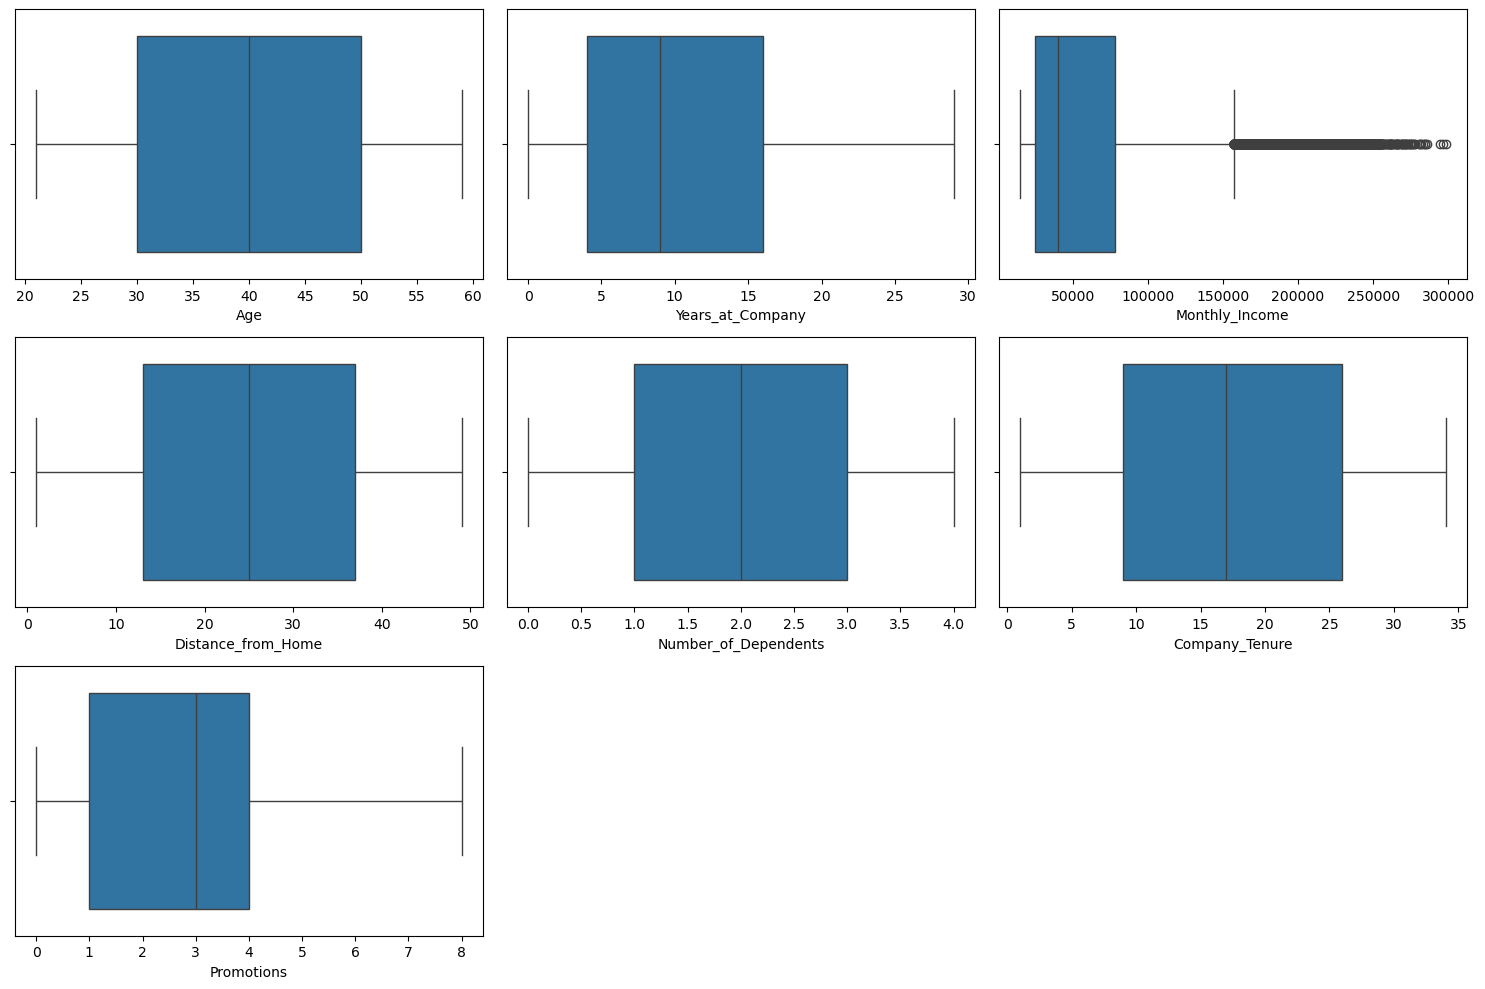

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'Age',
    'Years_at_Company',
    'Monthly_Income',
    'Distance_from_Home',
    'Number_of_Dependents',
    'Company_Tenure',
    'Promotions'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=data[col])

plt.tight_layout()
plt.show()

# Outlier Treatment

In [60]:
data['Monthly_Income_Log'] = np.log1p(data['Monthly_Income'])

In [61]:
data.drop('Monthly_Income', axis=1, inplace=True)

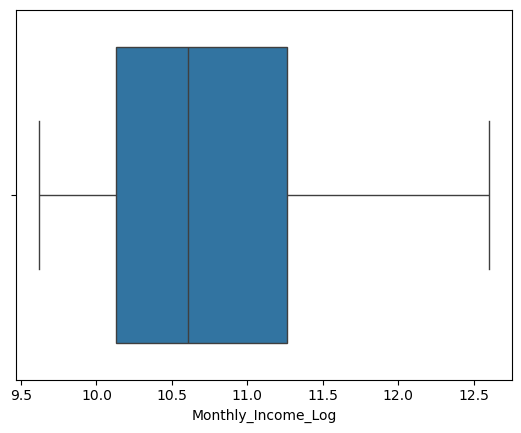

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=data['Monthly_Income_Log'])
plt.show()

# Feature Engineering

In [63]:
# Income per experience
data['Income_per_Year'] = data['Monthly_Income_Log'] / (data['Years_at_Company'] + 1)

# Work stress indicator
data['Work_Stress'] = (
    (data['Overtime'] == 'Yes').astype(int) +
    (data['Work_Life_Balance'].isin(['Poor','Fair'])).astype(int)
)

# Promotion growth
data['Promotion_Rate'] = data['Promotions'] / (data['Years_at_Company'] + 1)

In [65]:
data[['Years_at_Company', 'Monthly_Income_Log', 'Income_per_Year',
      'Promotions', 'Promotion_Rate', 'Work_Stress']].head(10)

,Years_at_Company,Monthly_Income_Log,Income_per_Year,Promotions,Promotion_Rate,Work_Stress
0,0,11.479038,11.479038,1,1.000000,1
1,21,9.942949,0.451952,5,0.227273,1
2,4,10.429221,2.085844,2,0.400000,1
3,7,9.916799,1.239600,2,0.250000,2
4,7,11.566428,1.445804,2,0.250000,0
5,23,9.835690,0.409820,6,0.250000,1
6,6,10.371239,1.481606,2,0.285714,1
7,22,10.944612,0.475853,5,0.217391,1
8,10,11.224096,1.020372,2,0.181818,0
9,10,12.116542,1.101504,3,0.272727,2


In [66]:
data[['Income_per_Year', 'Promotion_Rate', 'Work_Stress']].describe()

,Income_per_Year,Promotion_Rate,Work_Stress
count,100000.000000,100000.000000,100000.000000
mean,2.010838,0.248243,0.847350
std,2.512694,0.167185,0.690762
min,0.320529,0.000000,0.000000
25%,0.616625,0.200000,0.000000
50%,1.022397,0.241379,1.000000
75%,2.091044,0.285714,1.000000
max,12.521540,1.000000,2.000000


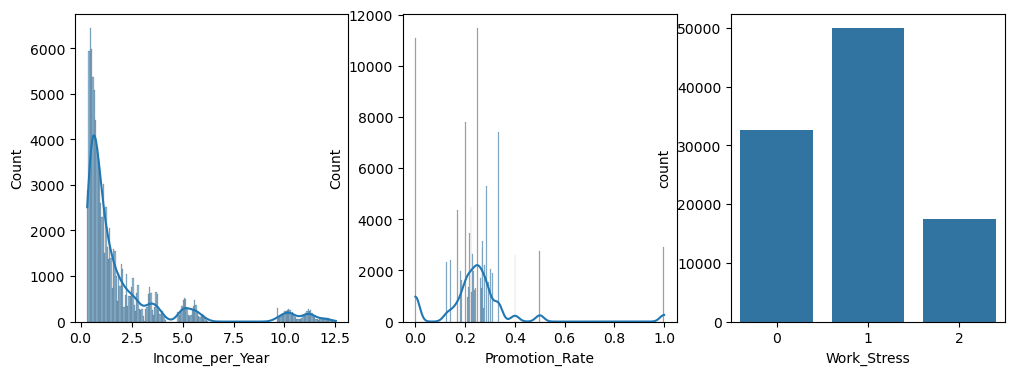

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(data['Income_per_Year'], kde=True)

plt.subplot(1,3,2)
sns.histplot(data['Promotion_Rate'], kde=True)

plt.subplot(1,3,3)
sns.countplot(x=data['Work_Stress'])

plt.show()

In [68]:
data_temp = data.copy()
data_temp['Attrition'] = data_temp['Attrition'].map({'Stayed':0, 'Left':1})

data_temp[['Income_per_Year', 'Promotion_Rate', 'Work_Stress', 'Attrition']].corr()

,Income_per_Year,Promotion_Rate,Work_Stress,Attrition
Income_per_Year,1.000000,0.298488,-0.001141,0.060125
Promotion_Rate,0.298488,1.000000,0.003318,-0.066170
Work_Stress,-0.001141,0.003318,1.000000,0.451485
Attrition,0.060125,-0.066170,0.451485,1.000000


# Encoding

In [69]:
ordinal_cols = [
    'Job_Level',
    'Work_Life_Balance',
    'Job_Satisfaction',
    'Performance_Rating',
    'Education_Level'
]

In [70]:
nominal_cols = [
    'Gender',
    'Job_Role',
    'Overtime',
    'Marital_Status',
    'Employee_Recognition'
]

In [71]:
from sklearn.preprocessing import OrdinalEncoder

education_order = ['High School','Diploma','Bachelor','Master','PhD']
job_level_order = ['Entry','Mid','Senior']
work_life_order = ['Poor','Fair','Good','Excellent']
job_sat_order = ['Low','Medium','High','Very High']
perf_order = ['Low','Average','High']

ordinal_encoder = OrdinalEncoder(categories=[
    job_level_order,
    work_life_order,
    job_sat_order,
    perf_order,
    education_order
])

data[ordinal_cols] = ordinal_encoder.fit_transform(data[ordinal_cols])

In [72]:
data = pd.get_dummies(data, columns=nominal_cols, drop_first=True)

In [73]:
data['Attrition'] = data['Attrition'].map({'Stayed':0, 'Left':1})

In [75]:
data.shape

(100000, 25)

In [76]:
X = data.drop('Attrition', axis=1)
y = data['Attrition']

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [78]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(80000, 24)
(20000, 24)
Attrition
0    0.588538
1    0.411463
Name: proportion, dtype: float64
Attrition
0    0.58855
1    0.41145
Name: proportion, dtype: float64


## Scaling Numerical Columns

In [79]:
num_cols = [
    'Age',
    'Years_at_Company',
    'Distance_from_Home',
    'Number_of_Dependents',
    'Company_Tenure',
    'Promotions',
    'Monthly_Income_Log',
    'Income_per_Year',
    'Promotion_Rate',
    'Work_Stress'
]

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [81]:
X_train.shape

(80000, 24)

In [82]:
X_test.shape

(20000, 24)

# Building BaseLine ANN

In [83]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_baseline = Sequential()

model_baseline.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model_baseline.add(Dense(16, activation='relu'))
model_baseline.add(Dense(1, activation='sigmoid'))

model_baseline.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

C:\Users\srira\anaconda3\envs\base_py310_clean\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
history_base = model_baseline.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64
)

Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8333 - loss: 0.3549 - val_accuracy: 0.8821 - val_loss: 0.2588
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8894 - loss: 0.2329 - val_accuracy: 0.8891 - val_loss: 0.2269
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8930 - loss: 0.2184 - val_accuracy: 0.8896 - val_loss: 0.2200
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8938 - loss: 0.2123 - val_accuracy: 0.8882 - val_loss: 0.2167
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8945 - loss: 0.2076 - val_accuracy: 0.8898 - val_loss: 0.2153
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8953 - loss: 0.2049 - val_accuracy: 0.8884 - val_loss: 0.2138
Epoch 7/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8961 - loss: 0.2030 - val_accuracy: 0.8890 - val_loss: 0.2126
Epoch 8/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8962 - loss: 0.2017 - 

In [85]:
loss, acc = model_baseline.evaluate(X_test, y_test)
print("Baseline ANN Accuracy:", acc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8933 - loss: 0.1851
Baseline ANN Accuracy: 0.8932999968528748


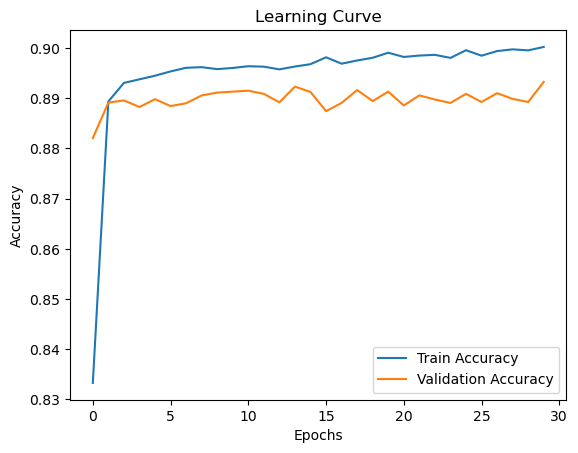

In [86]:
import matplotlib.pyplot as plt

plt.plot(history_base.history['accuracy'], label='Train Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [87]:
from sklearn.metrics import classification_report

y_pred = (model_baseline.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     11771
           1       0.87      0.87      0.87      8229

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



In [88]:
y_pred = (model_baseline.predict(X_test) > 0.4).astype(int)

print(classification_report(y_test, y_pred))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.94      0.88      0.91     11771
           1       0.84      0.92      0.88      8229

    accuracy                           0.90     20000
   macro avg       0.89      0.90      0.89     20000
weighted avg       0.90      0.90      0.90     20000



## improving model when layers are increasing it is becoming overfit

In [90]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_baseline2 = Sequential()

model_baseline2.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model_baseline2.add(Dense(128, activation='relu'))
model_baseline2.add(Dense(64, activation='relu'))
model_baseline2.add(Dense(32, activation='relu'))
model_baseline2.add(Dense(16, activation='relu'))
model_baseline2.add(Dense(4, activation='relu'))
model_baseline2.add(Dense(2, activation='relu'))

model_baseline2.add(Dense(1, activation='sigmoid'))

model_baseline2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

C:\Users\srira\anaconda3\envs\base_py310_clean\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [91]:
history_base = model_baseline2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64
)

Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8703 - loss: 0.2760 - val_accuracy: 0.8860 - val_loss: 0.2370
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8917 - loss: 0.2125 - val_accuracy: 0.8904 - val_loss: 0.2076
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8953 - loss: 0.2006 - val_accuracy: 0.8893 - val_loss: 0.2157
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8963 - loss: 0.1951 - val_accuracy: 0.8883 - val_loss: 0.2030
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8958 - loss: 0.1898 - val_accuracy: 0.8921 - val_loss: 0.1932
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8972 - loss: 0.1815 - val_accuracy: 0.8913 - val_loss: 0.2007
Epoch 7/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8978 - loss: 0.1757 - val_accuracy: 0.8911 - val_loss: 0.1879
Epoch 8/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8986 - loss: 0.1690 - 

In [92]:
loss, acc = model_baseline2.evaluate(X_test, y_test)
print("Baseline ANN Accuracy:", acc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8874 - loss: 0.2169
Baseline ANN Accuracy: 0.8874499797821045


## solving the overfit

In [93]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

model = Sequential()

model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

C:\Users\srira\anaconda3\envs\base_py310_clean\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## optimizer control

In [94]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

### compiling with business metrics

In [95]:
from tensorflow.keras.metrics import Recall, Precision

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', Recall(name='recall'), Precision(name='precision')]
)

In [96]:
## adding early stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_recall',
    patience=5,
    restore_best_weights=True
)

In [97]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7897 - loss: 0.5851 - precision: 0.7366 - recall: 0.7595 - val_accuracy: 0.8749 - val_loss: 0.4099 - val_precision: 0.8734 - val_recall: 0.8170
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8639 - loss: 0.4127 - precision: 0.8349 - recall: 0.8333 - val_accuracy: 0.8855 - val_loss: 0.3363 - val_precision: 0.8628 - val_recall: 0.8610
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8749 - loss: 0.3569 - precision: 0.8484 - recall: 0.8467 - val_accuracy: 0.8888 - val_loss: 0.3005 - val_precision: 0.8646 - val_recall: 0.8679
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8800 - loss: 0.3207 - precision: 0.8518 - recall: 0.8567 - val_accuracy: 0.8894 - val_loss: 0.2755 - val_precision: 0.8792 - val_recall: 0.8501
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8839 - loss: 0.2968 - precision: 0.8582 - recall: 0.8593 - val_accuracy: 0.890

In [98]:
loss, acc, recall, precision = model.evaluate(X_test, y_test)

print("Accuracy:", acc)
print("Recall:", recall)
print("Precision:", precision)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8937 - loss: 0.2426 - precision: 0.8679 - recall: 0.8748
Accuracy: 0.8937000036239624
Recall: 0.8748329281806946
Precision: 0.8678722381591797


# Learning curve

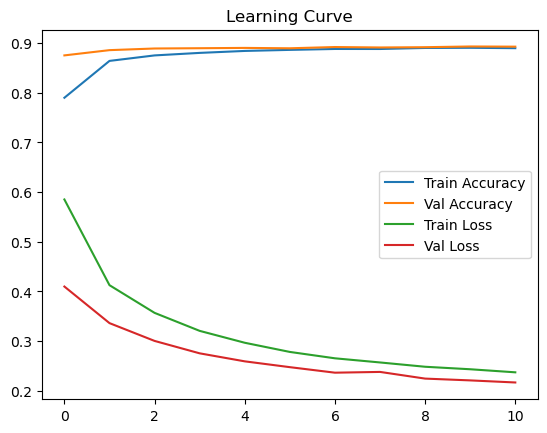

In [99]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.legend()
plt.title("Learning Curve")
plt.show()

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


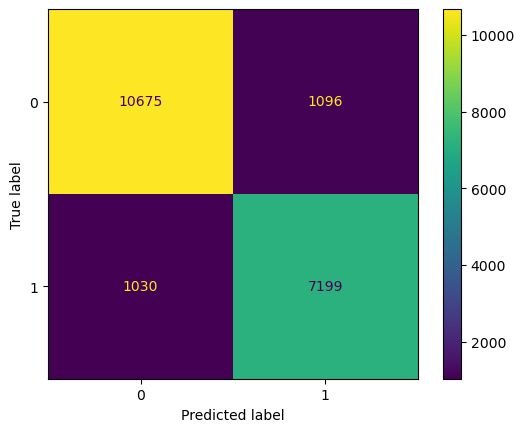

In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [101]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91     11771
           1       0.87      0.87      0.87      8229

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



In [103]:
y_prob = model.predict(X_test)

y_pred_custom = (y_prob > 0.4).astype(int)
y_pred_custom

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0],
       [1],
       [0],
       ...,
       [1],
       [0],
       [0]], shape=(20000, 1))

# hyper parameter tuning

In [106]:
import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.regularizers import l1
from tensorflow.keras.callbacks import EarlyStopping

def objective(trial):

    n_layers = trial.suggest_int('n_layers', 4, 6)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop', 'sgd'])
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    l1_reg = trial.suggest_float('l1', 1e-6, 1e-3, log=True)
    dropout_rate = trial.suggest_float('dropout', 0.2, 0.5)

    model = Sequential()
    model.add(Dense(64, activation=activation, input_shape=(X_train.shape[1],)))

    for i in range(n_layers):
        units = trial.suggest_int(f'units_{i}', 32, 128)
        model.add(Dense(units, activation=activation,
                        kernel_regularizer=l1(l1_reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=lr)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=lr)
    else:
        optimizer = SGD(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )

    return max(history.history['val_accuracy'])

In [107]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(study.best_params)

[I 2026-04-04 15:32:23,865] A new study created in memory with name: no-name-5b54ec0b-5c48-49eb-8aa0-7e7338211526
C:\Users\srira\anaconda3\envs\base_py310_clean\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-04-04 15:38:19,691] Trial 0 finished with value: 0.8158749938011169 and parameters: {'n_layers': 4, 'activation': 'tanh', 'optimizer': 'sgd', 'learning_rate': 0.00022898015104078935, 'l1': 1.5949846118878184e-05, 'dropout': 0.32669391911746615, 'units_0': 93, 'units_1': 40, 'units_2': 126, 'units_3': 111}. Best is trial 0 with value: 0.8158749938011169.
C:\Users\srira\anaconda3\envs\base_py310_clean\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to 

{'n_layers': 5, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.0013478102637632743, 'l1': 8.735435862756816e-06, 'dropout': 0.262888204915006, 'units_0': 80, 'units_1': 87, 'units_2': 53, 'units_3': 111, 'units_4': 91}


In [108]:
study.best_params

{'n_layers': 5,
 'activation': 'tanh',
 'optimizer': 'adam',
 'learning_rate': 0.0013478102637632743,
 'l1': 8.735435862756816e-06,
 'dropout': 0.262888204915006,
 'units_0': 80,
 'units_1': 87,
 'units_2': 53,
 'units_3': 111,
 'units_4': 91}

In [109]:
study.best_value

0.8959375023841858

## Building final model

In [110]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from tensorflow.keras.callbacks import EarlyStopping

model_final = Sequential()

model_final.add(Input(shape=(X_train.shape[1],)))

model_final.add(Dense(80, activation='tanh', kernel_regularizer=l1(8.735e-06)))
model_final.add(BatchNormalization())
model_final.add(Dropout(0.26))

model_final.add(Dense(87, activation='tanh', kernel_regularizer=l1(8.735e-06)))
model_final.add(BatchNormalization())
model_final.add(Dropout(0.26))

model_final.add(Dense(53, activation='tanh', kernel_regularizer=l1(8.735e-06)))
model_final.add(BatchNormalization())
model_final.add(Dropout(0.26))

model_final.add(Dense(111, activation='tanh', kernel_regularizer=l1(8.735e-06)))
model_final.add(BatchNormalization())
model_final.add(Dropout(0.26))

model_final.add(Dense(91, activation='tanh', kernel_regularizer=l1(8.735e-06)))
model_final.add(BatchNormalization())
model_final.add(Dropout(0.26))

model_final.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.0013478)

model_final.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_final = model_final.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8018 - loss: 0.4533 - val_accuracy: 0.8651 - val_loss: 0.3342
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8560 - loss: 0.3354 - val_accuracy: 0.8831 - val_loss: 0.2608
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8707 - loss: 0.2984 - val_accuracy: 0.8897 - val_loss: 0.2452
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8773 - loss: 0.2806 - val_accuracy: 0.8892 - val_loss: 0.2352
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8780 - loss: 0.2721 - val_accuracy: 0.8907 - val_loss: 0.2325
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8814 - loss: 0.2589 - val_accuracy: 0.8916 - val_loss: 0.2196
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8822 - loss: 0.2496 - val_accuracy: 0.8896 - val_loss: 0.2102
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8817 - loss: 0.2429 -

In [111]:
loss, acc = model_final.evaluate(X_test, y_test)
print("Final Accuracy:", acc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8945 - loss: 0.1782
Final Accuracy: 0.8945000171661377


In [131]:
y_prob = model_final.predict(X_test)
y_prob

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


array([[8.0179702e-04],
       [9.5958269e-01],
       [2.8943787e-03],
       ...,
       [9.9913538e-01],
       [1.8360629e-03],
       [1.2183059e-03]], shape=(20000, 1), dtype=float32)

In [133]:
risk_score = y_prob * 100
risk_score

array([[8.0179706e-02],
       [9.5958267e+01],
       [2.8943786e-01],
       ...,
       [9.9913536e+01],
       [1.8360628e-01],
       [1.2183059e-01]], shape=(20000, 1), dtype=float32)

In [134]:
def risk_category(score):
    if score < 30:
        return "Low Risk"
    elif score < 60:
        return "Medium Risk"
    else:
        return "High Risk"

risk_category_list = [risk_category(x[0]) for x in risk_score]

In [135]:
result_df = X_test.copy()

result_df['Attrition_Prob'] = y_prob
result_df['Risk_Score'] = risk_score
result_df['Risk_Category'] = risk_category_list

In [136]:
def retention_strategy(row):

    if row['Risk_Score'] < 30:
        return "No Action Needed"

    elif row['Risk_Score'] < 60:
        return "Engagement Program / Career Discussion"

    else:
        # High risk → smart logic
        if row['Work_Stress'] == 2:
            return "Reduce Workload + Wellness Program"
        elif row['Promotion_Rate'] < 0.1:
            return "Promotion / Role Upgrade"
        elif row['Income_per_Year'] < 1:
            return "Salary Hike"
        else:
            return "HR Intervention + Retention Bonus"

In [137]:
result_df['Retention_Action'] = result_df.apply(retention_strategy, axis=1)

In [138]:
result_df[['Risk_Score', 'Risk_Category', 'Retention_Action']].head()

,Risk_Score,Risk_Category,Retention_Action
87853,0.080180,Low Risk,No Action Needed
28515,95.958267,High Risk,Salary Hike
97206,0.289438,Low Risk,No Action Needed
20730,0.158187,Low Risk,No Action Needed
20780,0.149121,Low Risk,No Action Needed


In [143]:
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()


scaler.fit(X_train)

model_final.save("final_ann_model.h5")
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X_train.columns.tolist(), open("columns.pkl", "wb"))

In [144]:
print(X_train.columns)

Index(['Age', 'Years_at_Company', 'Job_Level', 'Work_Life_Balance',
       'Job_Satisfaction', 'Performance_Rating', 'Distance_from_Home',
       'Education_Level', 'Number_of_Dependents', 'Company_Tenure',
       'Promotions', 'Monthly_Income_Log', 'Income_per_Year', 'Work_Stress',
       'Promotion_Rate', 'Gender_Male', 'Job_Role_HR', 'Job_Role_IT',
       'Job_Role_Marketing', 'Job_Role_Sales', 'Overtime_Yes',
       'Marital_Status_Single', 'Employee_Recognition_Low',
       'Employee_Recognition_Medium'],
      dtype='object')


In [145]:
import numpy as np

importance = np.mean(np.abs(X_train), axis=0)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
Education_Level,Education_Level,2.001150
Work_Life_Balance,Work_Life_Balance,1.501525
Job_Satisfaction,Job_Satisfaction,1.498012
Performance_Rating,Performance_Rating,0.997437
Monthly_Income_Log,Monthly_Income_Log,0.878958
Distance_from_Home,Distance_from_Home,0.866973
Company_Tenure,Company_Tenure,0.866069
Age,Age,0.865466
Number_of_Dependents,Number_of_Dependents,0.849286
Years_at_Company,Years_at_Company,0.844962
